## Fotometría

### Correr autophot

In [1]:
import os
import pandas as pd
from copy import deepcopy
from autophot.prep_input import load
import shutil
autophot_input = load()

# -------------------------
# Parámetros
# -------------------------
BASE = "/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/sn_hsh_pipeline/process_HSH_SN"
noche = "20250823bis"
objname = "OGLE-2025-BLG-0675"
#objname = "OGLE-2025-GD-0001"

# -------------------------
# Coordenadas del target
coords_csv = os.path.join(BASE, "data", "objetos.csv")
coords = pd.read_csv(coords_csv)
row = coords[coords["objeto"] == objname]
assert not row.empty, f"{objname} no está en objetos.csv"
comb_files = [f for f in os.listdir(os.path.join(BASE, "data", noche, objname)) if "comb" in f]
assert len(comb_files)!=0, "Falta hacer combinación"
os.makedirs(os.path.join(BASE, "data", noche, objname, "phot"), exist_ok=True)
for f in comb_files:
    shutil.copy(os.path.join(BASE, "data", noche, objname,f),os.path.join(BASE, "data", noche, objname, "phot",f))

refcat_csv = os.path.join(BASE, "data", "objetos", objname, f"{objname}_cat.csv")
#refcat_csv = os.path.join(BASE, "axel0675_catBVRI.csv")

# -------------------------
# Paths absolutos
# -------------------------
fits_dir = os.path.join(BASE, "data", noche, objname, "phot")
wdir = os.path.join(BASE, "outputs", noche, objname)

os.makedirs(wdir, exist_ok=True)

# -------------------------
# Chequeos 
# -------------------------
assert os.path.isdir(fits_dir), f"No existe fits_dir: {fits_dir}"
assert os.path.isfile(coords_csv), f"No existe {coords_csv}"
assert os.path.isfile(refcat_csv), f"No existe {refcat_csv}"

fits_files = [f for f in os.listdir(fits_dir) if f.lower().endswith((".fits", ".fit"))]
assert len(fits_files) > 0, f"No hay FITS en {fits_dir}"



ra = float(row["ra_deg"].values[0])/15 # /15 to transform to hourangles
dec = float(row["dec_deg"].values[0])

# -------------------------
# Autophot input
# -------------------------

autophot_input["wdir"] = wdir
autophot_input["fits_dir"] = fits_dir

autophot_input["target_name"] = objname
autophot_input["target_ra"] = ra
autophot_input["target_dec"] = dec

autophot_input["catalog"]["use_catalog"] = "custom"
autophot_input["catalog"]["catalog_custom_fpath"] = refcat_csv
autophot_input["catalog"]["catalog_radius"] = 0.07
autophot_input['photometry']['snr_calib'] = 10
# autophot_input['catalog']['catalog'] = "apass"
autophot_input['photometry']['do_ap_phot'] = True
autophot_input['photometry']['ap_size'] = 1.5
autophot_input['plot_source_selection'] = False

#autophot_input['select_filter'] = True
#autophot_input['do_filter'] = ["I"]
# autophot_input['photometry']['find_optimum_radius'] =True

# autophot_input['psf']['isolate_sources'] = False          # Desactiva el chequeo de fuentes cercanas débiles
# autophot_input['psf']['min_snr_psf'] = 50                 # Baja el SNR mínimo para estrellas PSF (default suele ser alto)
# autophot_input['psf']['max_snr_psf'] = 1000                # Evita saturadas
# autophot_input['catalog']['faint_mag_cut'] = 18            # Limita a estrellas más brillantes para PSF
# === Mejoras en calibración (reduce scatter alto) ===

autophot_input['catalog']['catalog_radius'] = 0.1  # Aumenta ligeramente para más estrellas, pero no >0.15 (evita más crowding)
autophot_input['catalog']['matching_source_FWHM_limit'] = 40  # Baja para ser más tolerante con FWHM variables
autophot_input['catalog']['catalog_matching_limit'] = 17  # Menos matches para calidad
autophot_input['catalog']['max_catalog_sources'] = 100  # Limita a ~100 para evitar saturadas/blendadas

# === Fotometría: Fuerza PSF (mejor para crowding que aperture) ===
autophot_input['photometry']['do_ap_phot'] = False  # Desactiva aperture como principal
autophot_input['photometry']['force_psf'] = False # Fuerza PSF
autophot_input['photometry']['snr_calib'] = 5       # Baja SNR corte para calibración (usa más estrellas, pero chequea manual)
# autophot_input['photometry']['find_optimum_radius'] = True
autophot_input['photometry']['ap_size'] = 1.1
# === PSF settings (evita fallos por "faint sources near") ===
autophot_input['psf']['psf_source_no'] = 30          # Usa más estrellas para modelo PSF
autophot_input['psf']['min_psf_source_no'] = 5       # Mínimo para construir
autophot_input['psf']['construction_SNR'] = 6       # Baja para incluir más
autophot_input['psf']['plot_PSF_residuals'] = True   # Activa plots para inspeccionar residuals (busca blending)

# === Source detection: Más estricto para outliers ===
autophot_input['source_detection']['threshold_value'] = 10  # Baja de 25 para detectar más, pero filtra después
autophot_input['source_detection']['remove_sat'] = True
autophot_input['source_detection']['pix_bound'] = 50  # Más margen de bordes

# === Zeropoint: Usa media y sigma clip más agresivo ===
autophot_input['zeropoint']['zp_sigma'] = 2.0  # Sigma clip más estricto (quita outliers)
autophot_input['zeropoint']['zp_use_mean'] = True
autophot_input['zeropoint']['matching_source_SNR_limit'] = 10  # Baja para más puntos en ZP

# === Otros útiles ===
autophot_input['limiting_magnitude']['skip_lmag'] = False  # Calcula limiting mag para chequear
autophot_input['wcs']['search_radius'] = 0.3  # Aumenta si WCS falla
autophot_input['cosmic_rays']['remove_cmrays'] = True

# === Clave: ser menos estricto con el aislamiento de estrellas PSF ===
autophot_input['psf']['construction_SNR'] = 3          # Baja de 10 → permite estrellas más débiles
autophot_input['psf']['psf_source_no'] = 20           # Intenta usar hasta 20 (default 15)
autophot_input['psf']['min_psf_source_no'] = 3        # Mínimo aceptable

# === Relaja el rechazo por fuentes débiles cercanas (principal causa del fallo) ===
# No hay parámetro directo, pero bajar el umbral de detección ayuda indirectamente
autophot_input['source_detection']['threshold_value'] = 8   # De 10 → detecta más, pero el aislamiento es menos estricto
autophot_input['source_detection']['isolate_sources_fwhm_sep'] = 2  # De 5 → permite estrellas más cerca (menos rechazos)

# === Zeropoint más robusto ===
autophot_input['zeropoint']['matching_source_SNR_limit'] = 8   # De 10 → usa más estrellas en calibración
autophot_input['zeropoint']['zp_sigma'] = 3.0                  # Clip menos agresivo

# === Catálogo: un poco más grande para tener más candidatas PSF ===
autophot_input['catalog']['catalog_radius'] = 0.15   # De 0.1 → más estrellas brillantes posibles
autophot_input['catalog']['max_catalog_sources'] = 150
# Mueve el annulus más lejos para evitar esa estrella contaminante
autophot_input['photometry']['r_in_size'] = 3    # Era 2 → radio interno más grande
autophot_input['photometry']['r_out_size'] = 5   # Era 3 → anillo más externo y ancho

# Opcional: usa background local más robusto (recomendado en campos crowded)
autophot_input['fitting']['remove_bkg_local'] = True
autophot_input['fitting']['remove_bkg_surface'] = False
autophot_input['fitting']['bkg_level'] = 3         # Baja un poco si usas local
autophot_input['target_photometry']['adjust_SN_loc'] = False,

# -------------------------
# Log rápido
# -------------------------
print(f"WDIR     : {wdir}")
print(f"FITS DIR : {fits_dir}")
print(f"CATALOG  : {refcat_csv}")
print(f"TARGET   : {objname}")
print(f"N FITS   : {len(fits_files)}")



Default input loaded in from: 
/home/knowogrodski/Documentos/observation_HSH/process_HSH_SN/autophot/autophot/databases/default_input.yml
WDIR     : /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/sn_hsh_pipeline/process_HSH_SN/outputs/20250823bis/OGLE-2025-BLG-0675
FITS DIR : /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/sn_hsh_pipeline/process_HSH_SN/data/20250823bis/OGLE-2025-BLG-0675/phot
CATALOG  : /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/sn_hsh_pipeline/process_HSH_SN/data/objetos/OGLE-2025-BLG-0675/OGLE-2025-BLG-0675_cat.csv
TARGET   : OGLE-2025-BLG-0675
N FITS   : 20


In [7]:
import os
os.getcwd(), autophot_input

('/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/sn_hsh_pipeline/process_HSH_SN/data/20250823bis/OGLE-2025-BLG-0675/phot_REDUCED',
 {'fits_dir': '/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/sn_hsh_pipeline/process_HSH_SN/data/20250823bis/OGLE-2025-BLG-0675/phot',
  'method': 'sp',
  'ignore_no_telescop': False,
  'outdir_name': 'REDUCED',
  'outcsv_name': 'REDUCED',
  'ignore_no_filter': True,
  'restart': False,
  'select_filter': False,
  'do_filter': [None],
  'target_name': 'OGLE-2025-BLG-0675',
  'target_ra': 18.461022222222223,
  'target_dec': -26.628805555555555,
  'plot_source_selection': False,
  'preprocessing': {'trim_edges': False,
   'trim_edges_pixels': 50,
   'mask_sources': False,
   'mask_sources_RADEC_R': None,
   'mask_sources_XY_R': []},
  'photometry': {'do_ap_phot': False,
   'force_psf': False,
   'use_local_stars': False,
   'use_local_stars_for_FWHM': False,
   'use_local_stars_for_PSF': False,
   'use_source_arcmin': 4,
   'local_radius': 

In [3]:
# Import automated photometry script and pass input dictionary
from autophot.autophot_main import run_automatic_autophot

run_automatic_autophot(autophot_input)



        _       _       ___ _  _    _____
       /_\ _  _| |_ ___| _ \ || |__|_   _|
      / _ \ || |  _/ _ \  _/ __ / _ \| |
     /_/ \_\_,_|\__\___/_| |_||_\___/|_|
    
     ---------------------------------------
        Automated Photometry of Transients
        S. J. Brennan et al. 2021 
        Please provide feedback/bugs to:
        Email: sean.brennan2@ucdconnect.ie
    ---------------------------------------
Directory of fits file: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/sn_hsh_pipeline/process_HSH_SN/data/20250823bis/OGLE-2025-BLG-0675/phot
Found Telescopes:

 - HSH

-> Telescope check complete

Checking Filter keywords and database

-> Filter check complete

Checking Filter information for each image

Files removed - Wrong Image Type: 0

Files removed - No/Wrong filter(s): 0
Filters not included: []


Files removed: 0

+------------+
|File: 1 / 20|
+------------+



File: OGLE-2025-BLG-0675_v_comb_APT.fits - PID: 55290
Start Time: 2026-01-22 13:19:59.535969
Filter keyoward used: FILTERS
Telescope: HSH
Filter: V
MJD: 60911.184
Date of Observation : 2025-08-24
Read Noise: 15.7 [e^- /pixel]
GAIN: 2.0 [e^- /count]
Exposure time: 120 [s] 
Detecting/removing cosmic ray sources


Starting Astroscrappy ... 

Contaminated pixels with Cosmic rays removed: 595
Cosmic rays removed - image updated
WCS found

Searching for FWHM
Using Gaussian Profile for fitting



+-------------------------------+
|Finding Full Width Half Maximum|
+-------------------------------+



...

Fitting source for FWHM: 154/154  

Removed 15 FWHM outliers
Removed 10 median outliers
Useable sources found [ 16 sigma ]: 154
Removes 0 sources within minimum seperation [ 14 pixel ]

FWHM: 7.151 +/- 0.695 [ pixels ]

Seeing: 3.998 [ arcsec ]
Aperture size: 7.9 pixels
Aperture correction: -0.266 +/- 0.260 [ mag ]
Catalog length: 273
Removed 0 sources fainter than cutoff [17 mag]
Using Gaussian Profile for fitting
Catalog Length: 181



+--------------------------------------------+
|Searching for catalog for OGLE-2025-BLG-0675|
+--------------------------------------------+


+---------------------------------+
|Matching catalog sources to image|
+---------------------------------+

Removed 1 sources too close to target
Removed 91 sources too close to boundary or off image
Matching catalog to image: 114 / 181 :: Useful sources 114 / 181 

/home/knowogrodski/Documentos/observation_HSH/process_HSH_SN/autophot/autophot/autophot_main.py:25: DeprecationWarning: invalid escape sequence \A
  '''


KeyboardInterrupt: 

### Catálogo de referencia

#### Generación

In [ ]:
from astroquery.gaia import Gaia
import pandas as pd
import numpy as np
objname = "OGLE-2025-GD-0001"
os.makedirs(os.path.join(BASE, "data", "objetos", objname), exist_ok=True)
min_mag = 6
max_mag = 15
objetos = pd.read_csv(os.path.join('/home/knowogrodski/Documentos/observation_HSH/process_HSH_SN/data',"objetos.csv"))
ra  = objetos[objetos["objeto"]==objname]["ra_deg"].values[0]
dec = objetos[objetos["objeto"]==objname]["dec_deg"].values[0]
radius = 0.1  # grados (~3 arcmin)

# ============================================================
# 2. Query Gaia DR3 (estrellas brillantes y limpias)
# ============================================================
query = f"""
SELECT
    source_id,
    ra, dec,
    phot_g_mean_mag,
    phot_g_mean_flux_over_error,
    phot_bp_mean_mag,
    phot_bp_mean_flux_over_error,
    phot_rp_mean_mag,
    phot_rp_mean_flux_over_error
FROM gaiadr3.gaia_source
WHERE
    CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', {ra}, {dec}, {radius})
    ) = 1
    AND phot_g_mean_mag BETWEEN {min_mag} AND {max_mag}
    AND duplicated_source = 'false'
    AND phot_g_mean_flux_over_error > 100
    AND phot_bp_mean_flux_over_error > 50
    AND phot_rp_mean_flux_over_error > 50
"""#    AND visibility_periods_used >= 8
#"""

job = Gaia.launch_job(query)
df = job.get_results().to_pandas()
# ============================================================
# 3. Magnitudes Gaia y color
# ============================================================
df["G"]  = df["phot_g_mean_mag"]
df["BP"] = df["phot_bp_mean_mag"]
df["RP"] = df["phot_rp_mean_mag"]

df["color"] = df["BP"] - df["RP"]

# ------------------------------------------------------------
# Rango válido del polinomio
# https://gea.esac.esa.int/archive/documentation/GDR2/Data_processing/chap_cu5pho/sec_cu5pho_calibr/ssec_cu5pho_PhotTransf.html
# ------------------------------------------------------------
df = df[(df["color"] > -0.5) & (df["color"] < 2.75)]
'''
G−V=f(GBP−GRP)    −0.5<GBP−GRP<2.75
G−I=f(GBP−GRP)    −0.5<GBP−GRP<2.75
'''

# ============================================================
# 4. Transformaciones Gaia → Johnson–Cousins
#    https://gea.esac.esa.int/archive/documentation/GDR2/Data_processing/chap_cu5pho/sec_cu5pho_calibr/ssec_cu5pho_PhotTransf.html
# ============================================================
'''
		       GBP−GRP    (GBP−GRP)2          σ
G−V -0.01760	-0.006860	-0.1732			0.045858
G−I 0.02085	    0.7419	    -0.09631		0.04956
'''
# --- Johnson V ---
df["V"] = (
    df["G"]
    + 0.01760
    + 0.00686 * df["color"]
    + 0.1732  * df["color"]**2
)

# --- Cousins I ---
df["I"] = (
    df["G"]
    - 0.02085
    - 0.7419  * df["color"]
    + 0.09631 * df["color"]**2
)

# ============================================================
# 5. Errores fotométricos Gaia
# ============================================================
# 1.0857 = 2.5 / ln(10)
df["G_err"]  = 1.0857 / df["phot_g_mean_flux_over_error"]
df["BP_err"] = 1.0857 / df["phot_bp_mean_flux_over_error"]
df["RP_err"] = 1.0857 / df["phot_rp_mean_flux_over_error"]

df["color_err"] = np.sqrt(df["BP_err"]**2 + df["RP_err"]**2)

# ============================================================
# 6. Propagación correcta de errores (incluye σ del paper)
# ============================================================

# Coeficientes del polinomio
a1_V, a2_V = 0.00686, 0.1732
a1_I, a2_I = -0.7419, 0.09631

# Dispersión residual del paper
sigma_pol_V = 0.045858
sigma_pol_I = 0.04956

df["V_err"] = np.sqrt(
    df["G_err"]**2
    + (a1_V + 2*a2_V*df["color"])**2 * df["color_err"]**2
    + sigma_pol_V**2
)

df["I_err"] = np.sqrt(
    df["G_err"]**2
    + (a1_I + 2*a2_I*df["color"])**2 * df["color_err"]**2
    + sigma_pol_I**2
)
# ============================================================
# 7. Catálogo final para fotometría (autophot-ready)
# ============================================================
cols_out = ["SOURCE_ID", "RA", "DEC","G", "G_err",
    "BP", "BP_err","RP", "RP_err","color", "color_err",
    "V", "V_err","I", "I_err"]
df = df.rename(columns={'ra': 'RA', 'dec': 'DEC'})
df[cols_out].to_csv(os.path.join(BASE, "data", "objetos", objname, f"{objname}_cat.csv"), index=False)

print("✅ Catálogo de estrellas de referencia VI generado correctamente.")


In [12]:
header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 1024                                                  
NAXIS2  =                 1024                                                  
CCDSIZE = '[1:1024,1:1024] '     / CCD size                                     
CCDSUM  = '1 1 '                 / CCD binning factors                          
PIXSIZE1=                 24.0   / pixel size for axis 1 (um)                   
PIXSIZE2=                 24.0   / pixel size for axis 2 (um)                   
ADCRATE = '          '           / analog to digital converter rate             
GAIN    =                  2.0 / CCD gain (e-/ADU)                              
RDNOISE =                 15.7 / Readout noise (e- RMS)                         
CAMTEM  =                -46

Transformación Gaia → I, V (de Axel)

#### Visualización del catálogo

In [8]:

import pandas as pd

my_first_catalog = pd.read_csv(autophot_input["catalog"]["catalog_custom_fpath"])
print(autophot_input["catalog"]["catalog_custom_fpath"])
my_first_catalog.head(10)



/home/knowogrodski/Documentos/observation_HSH/process_HSH_SN/data/objetos/OGLE-2025-BLG-0675/OGLE-2025-BLG-0675_cat.csv


,SOURCE_ID,RA,DEC,G,G_err,BP,BP_err,RP,RP_err,color,color_err,V,V_err,I,I_err
0,4052007391394801280,276.963985,-26.706170,13.174991,0.000220,13.605716,0.001060,12.572029,0.000852,1.033687,0.001361,13.384747,0.045861,12.490156,0.049566
1,4052052947992395136,276.915024,-26.697685,14.697700,0.000280,15.384852,0.001909,13.886270,0.001288,1.498583,0.002303,15.114544,0.045875,13.781340,0.049572
2,4052053055429113088,276.885685,-26.696571,14.215426,0.001040,14.952476,0.017112,12.978206,0.013867,1.974271,0.022025,14.921658,0.048327,13.105256,0.050207
3,4052053467813405952,276.846123,-26.685961,14.541894,0.000307,14.937412,0.001684,13.961298,0.001304,0.976114,0.002130,14.731215,0.045865,13.888629,0.049575
4,4052053875709991808,276.864160,-26.671501,14.946489,0.000385,15.402226,0.002596,14.253044,0.002581,1.149181,0.003661,15.200704,0.045884,14.200250,0.049598
5,4052054051928474240,276.868283,-26.657022,13.292522,0.000723,14.390232,0.002968,12.248747,0.001834,2.141485,0.003489,14.119101,0.045938,12.124577,0.049579
6,4052054665977430400,276.923157,-26.663017,12.396740,0.000505,13.395469,0.002360,11.413693,0.001433,1.981775,0.002761,13.108166,0.045901,11.283862,0.049573
7,4052054670403673984,276.920140,-26.666686,14.185679,0.000236,14.677205,0.001359,13.526545,0.002101,1.150661,0.002502,14.440494,0.045870,13.438671,0.049578
8,4052055112656380544,277.019953,-26.615574,14.266199,0.000684,15.358422,0.003413,13.226494,0.001518,2.131928,0.003735,15.085638,0.045948,13.101412,0.049580
9,4052055284455150080,276.960150,-26.605759,13.745618,0.000295,14.583728,0.003845,12.846744,0.000762,1.736984,0.003920,14.297698,0.045921,12.726677,0.049587


/home/knowogrodski/miniconda3/envs/autophot_env/lib/python3.7/site-packages/ipykernel_launcher.py:36: MatplotlibDeprecationWarning: Passing parameters norm and vmin/vmax simultaneously is deprecated since 3.3 and will become an error two minor releases later. Please pass vmin/vmax directly to the norm when creating it.


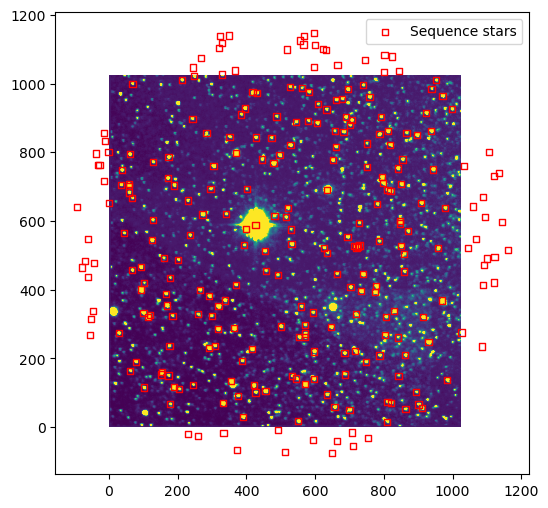

In [9]:

# We will plot out the image 
import matplotlib.pyplot as plt
from astropy.visualization import ImageNormalize,SquaredStretch,ZScaleInterval


# autophot functions to find image data and header from fits files
from autophot.packages.functions import getimage
from autophot.packages.functions import getheader

# To retrieve the WCS information from this image
from astropy import wcs
from astropy.coordinates import SkyCoord 
# noche = "20250822bis"
# objname = "OGLE-2025-BLG-0451"
impath = f'{autophot_input["fits_dir"]}/{objname}_v_comb.fits'
# image
data = getimage(impath)

# header
header = getheader(impath)

# Create an ImageNormalize object
norm = ImageNormalize(stretch = SquaredStretch())
vmin,vmax = (ZScaleInterval(nsamples = 1000)).get_limits(data)



fig = plt.figure(figsize = (10,6))

ax1 = fig.add_subplot(111)
ax1.imshow(data,
          vmin = vmin,
          vmax = vmax,
          norm = norm,
          origin = 'lower',
          cmap = 'viridis')



w = wcs.WCS(header)


# Plot our sequence stars
ra_stars = my_first_catalog['RA']
dec_stars = my_first_catalog['DEC']

x_pix_stars,y_pix_stars = w.all_world2pix(ra_stars, dec_stars, 0)

ax1.scatter(x_pix_stars,y_pix_stars,
            marker = 's',
            facecolor = 'none',
            edgecolor = 'r',
            s = 20,
            label = 'Sequence stars'
           )



plt.legend(loc= 'best')

plt.show()

In [ ]:
import numpy as np

number_of_sources = 200

ncols = 20
nrows = int(np.ceil(number_of_sources/ncols))
fig, axes = plt.subplots(nrows, ncols,figsize = (8,8),sharex=True, sharey=True, 
                         gridspec_kw={'wspace': 0.0, 'hspace': 0.1})

fig.suptitle('Sample of %d sources from custom catalog' % number_of_sources)


cutout_size = 15


stars_xy = list(zip(x_pix_stars,y_pix_stars))
axes = axes.flatten()
for i in range(number_of_sources):

    
    x,y = stars_xy[i]
    
    star_cutout = data[int(y - cutout_size):int(y + cutout_size),
                       int(x - cutout_size):int(x + cutout_size),]
                      
    
    axes[i].imshow(star_cutout,aspect='equal',origin = 'lower')
    axes[i].axis('off')
    

plt.show()

In [10]:
header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                 1024                                                  
NAXIS2  =                 1024                                                  
CCDSIZE = '[1:1024,1:1024] '     / CCD size                                     
CCDSUM  = '1 1 '                 / CCD binning factors                          
PIXSIZE1=                 24.0   / pixel size for axis 1 (um)                   
PIXSIZE2=                 24.0   / pixel size for axis 2 (um)                   
ADCRATE = '          '           / analog to digital converter rate             
GAIN    =                  2.0 / CCD gain (e-/ADU)                              
RDNOISE =                 15.7 / Readout noise (e- RMS)                         
CAMTEM  =                -46

#### Testing fotometría del catálogo (aperture, fwhm)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.stats import sigma_clipped_stats
from astropy.coordinates import SkyCoord
import astropy.units as u
from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture, aperture_photometry
import pandas as pd
import sep

# === Configuración (ajusta según tu caso) ===
fits_path = f'/home/knowogrodski/Documentos/observation_HSH/process_HSH_SN/data/20250822bis/{objname}/phot/{objname}_i_comb.fits'
fits_path = f'/home/knowogrodski/Documentos/observation_HSH/process_HSH_SN/data/20250822bis/OGLE-2025-GD-0001/FBOGLE-2025-GD-0001_i0003_wcs.fit'
catalog_path = refcat_csv
target_ra = row["ra_deg"].values[0]
target_dec = row["dec_deg"].values[0]
fwhm = 6.8                     # De tu log AutoPHOT
aperture_radius_pix = 10.2 / 2  # Radio de apertura (mitad del diámetro usado por AutoPHOT)

def check_photometry_issues(fits_path, catalog_path, target_ra, target_dec, fwhm, aperture_radius_pix):
    # 1. Cargar imagen
    with fits.open(fits_path) as hdul:
        data = hdul[0].data.astype(float)
        header = hdul[0].header
        wcs = WCS(header)

    print(f"Dimensiones de la imagen: {data.shape[1]} x {data.shape[0]} píxeles")

    # Estadísticas
    mean, median, std = sigma_clipped_stats(data, sigma=3.0)
    print(f"Estadísticas: Media={mean:.2f}, Mediana={median:.2f}, STD={std:.2f} ADU")

    # Bad pixels / NaNs
    n_nan = np.sum(np.isnan(data))
    if n_nan > 0:
        print(f"Advertencia: {n_nan} píxeles NaN encontrados (bad pixels o máscara).")

    # 2. Detección de fuentes
    bkg = sep.Background(data)
    data_sub = data - bkg.globalback
    sources_sep = sep.extract(data_sub, thresh=3.0, err=bkg.globalrms)
    print(f"Fuentes detectadas con SEP: {len(sources_sep)}")

    # Fuentes brillantes con DAOStarFinder
    daofind = DAOStarFinder(fwhm=fwhm, threshold=50.*std, sharplo=0.2, sharphi=2.0, roundlo=-1.0, roundhi=1.0)
    daosources = daofind(data_sub)
    if daosources is not None:
        print(f"Fuentes brillantes (DAOStarFinder): {len(daosources)}")
        # Detección de saturación: píxeles con valor > 50000 (típico para CCDs) o muy cercanos al máximo observado
        max_val = np.nanmax(data)
        sat_threshold = min(50000, 0.95 * max_val)  # Ajusta según tu cámara
        saturated = daosources['peak'] > sat_threshold
        n_sat = np.sum(saturated)
        if n_sat > 0:
            print(f"Advertencia: {n_sat} fuentes posiblemente saturadas (pico > {sat_threshold:.0f} ADU).")
        else:
            print("No se detectaron fuentes claramente saturadas.")
    else:
        print("No se encontraron fuentes brillantes con DAOStarFinder.")
        daosources = None

    # 3. Cargar catálogo y proyectar
    catalog = pd.read_csv(catalog_path)
    cat_coords = SkyCoord(ra=catalog['RA'].values*u.deg, dec=catalog['DEC'].values*u.deg)
    x_cat, y_cat = wcs.world_to_pixel(cat_coords)
    # Filtrar fuentes dentro de la imagen
    h, w = data.shape
    on_image = (x_cat >= 0) & (x_cat < w) & (y_cat >= 0) & (y_cat < h)
    catalog = catalog[on_image]
    x_cat = x_cat[on_image]
    y_cat = y_cat[on_image]
    print(f"Estrellas de catálogo dentro del campo: {len(catalog)}")

    # 4. Posición del objetivo
    target_coord = SkyCoord(ra=target_ra*u.deg, dec=target_dec*u.deg)
    target_x, target_y = wcs.world_to_pixel(target_coord)
    print(f"Posición del objetivo: x={target_x:.2f}, y={target_y:.2f}")

    # 5. Chequear blending
    if len(sources_sep) > 0:
        dist_to_target = np.sqrt((sources_sep['x'] - target_x)**2 + (sources_sep['y'] - target_y)**2)
        nearby = dist_to_target < 2 * fwhm  # Dentro de ~2×FWHM
        num_nearby = np.sum(nearby)
        if num_nearby > 1:  # Incluye el objetivo mismo
            print(f"Advertencia: {num_nearby - 1} fuentes adicionales cerca del objetivo (posible blending).")
        else:
            print("Objetivo bien aislado.")
    else:
        print("No se pudo evaluar blending (no fuentes detectadas).")

    # 6. Fotometría simple del objetivo
    aperture = CircularAperture([(target_x, target_y)], r=aperture_radius_pix)
    phot_table = aperture_photometry(data, aperture)
    flux = phot_table['aperture_sum'][0]
    area = np.pi * aperture_radius_pix**2
    noise = np.sqrt(flux + area * std**2 + area**2 * bkg.globalrms**2)  # Poisson + background + readnoise approx
    snr = flux / noise
    print(f"Flux objetivo (apertura {aperture_radius_pix:.1f} pix): {flux:.1f} ADU")
    print(f"SNR aproximado: {snr:.1f}")

    # 7. Chequeo de calibración (scatter)
    positions_cat = np.transpose((x_cat, y_cat))
    apertures_cat = CircularAperture(positions_cat, r=aperture_radius_pix)
    phot_cat = aperture_photometry(data, apertures_cat)

    flux_cat = phot_cat['aperture_sum']
    valid = (flux_cat > 0) & np.isfinite(flux_cat) & (catalog['I'] < 18)  # Filtra malas y muy débiles
    inst_mag = -2.5 * np.log10(flux_cat[valid])
    cat_mag = catalog['I'][valid].values

    zp_approx = np.median(cat_mag - inst_mag)
    residuals = (inst_mag + zp_approx) - cat_mag
    rms = np.std(residuals)
    print(f"\nZero-point aproximado (apertura): {zp_approx:.3f}")
    print(f"RMS de residuos en calibración: {rms:.3f} mag")
    if rms > 0.15:
        print("→ Scatter alto: posible blending, mala substracción de cielo o outliers.")
    else:
        print("→ Calibración consistente.")

    # 8. Plots
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(data, cmap='gray', origin='lower', vmin=median-3*std, vmax=median+15*std)
    plt.colorbar(label='ADU')
    plt.scatter(target_x, target_y, s=150, marker='x', color='red', label='Objetivo')
    #plt.scatter(x_cat, y_cat, s=40, facecolors='none', edgecolors='lime', label='Catálogo')
    #if daosources is not None:
    #    plt.scatter(daosources['xcentroid'], daosources['ycentroid'], s=60, marker='+', color='yellow', label='Brillantes')
    aperture.plot(color='orange', lw=1.5, label='Apertura')
    plt.legend()
    plt.title('Imagen con marcas')

    plt.subplot(1, 2, 2)
    plt.scatter(cat_mag, inst_mag + zp_approx, alpha=0.7)
    min_mag = min(cat_mag.min(), (inst_mag + zp_approx).min())
    max_mag = max(cat_mag.max(), (inst_mag + zp_approx).max())
    plt.plot([min_mag, max_mag], [min_mag, max_mag], 'r--', lw=2)
    plt.xlabel('Magnitud catálogo I')
    plt.ylabel('Magnitud instrumental + ZP')
    plt.title(f'Calibración (RMS = {rms:.3f} mag)')
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Ejecutar
check_photometry_issues(fits_path, catalog_path, target_ra, target_dec, fwhm, aperture_radius_pix)

In [ ]:
"FBOGLE-2025-BLG-0675v0012_wcs.fits".split('_')[0][2:-5]

## Combinación

### Visualización

Simple plot

Plot con extra data

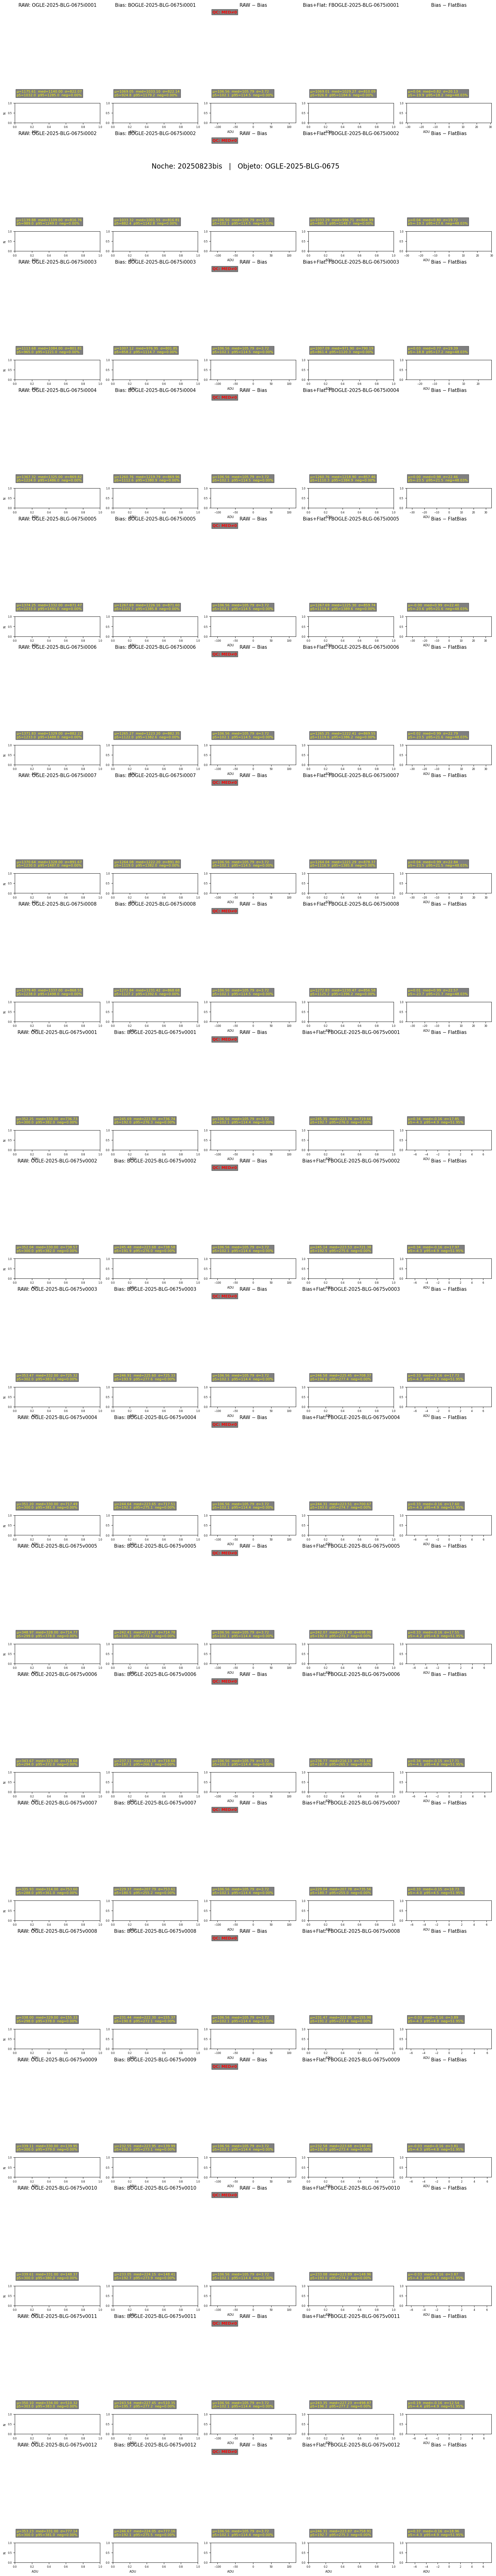

In [ ]:
import os
from pathlib import Path
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

data_path = Path(BASE, "data", noche)
files = [f for f in os.listdir(data_path) if objname in f]

raw = sorted([f for f in files if not f.startswith("B") and not f.startswith("FB") and "." in f and "fit" in f])
bias = sorted([f for f in files if f.startswith("B") and not f.startswith("FB") and "fit" in f])
flatbias = sorted([f for f in files if f.startswith("FB") and "fit" in f ])

def read_fits_data(path):
    with fits.open(path) as hdul:
        return hdul[0].data.astype(float)

def img_stats(img):
    return {
        "mean": np.mean(img),
        "median": np.median(img),
        "std": np.std(img),
        "p5": np.percentile(img, 5),
        "p95": np.percentile(img, 95),
        "neg_frac": np.mean(img < 0)
    }


n = len(raw)

# Umbrales de control de calidad
MEDIAN_TOL = 5.0       # ADU: cuán cerca de cero debe quedar RAW-Bias
NOISE_RATIO = 0.95     # std(RAW-Bias) < NOISE_RATIO * std(RAW)
NEG_FRAC_MAX = 0.01    # fracción máxima de píxeles negativos tolerada

fig = plt.figure(figsize=(20, 5*n))
gs = GridSpec(
    nrows=2*n, ncols=5,
    height_ratios=[4, 1]*n,   # imagen / hist absoluto
    hspace=0.30, wspace=0.15
)

for i in range(n):
    row_img  = 2*i
    row_hist = 2*i + 1

    raw_img = read_fits_data(data_path / raw[i])
    b_img   = read_fits_data(data_path / bias[i])
    fb_img  = read_fits_data(data_path / flatbias[i])

    diff_rb = raw_img - b_img
    diff_bf = b_img - fb_img

    vmin = np.percentile(raw_img, 5)
    vmax = np.percentile(raw_img, 99)

    dmax_rb = np.percentile(np.abs(diff_rb), 99)
    dmax_bf = np.percentile(np.abs(diff_bf), 99)

    images = [raw_img, b_img, diff_rb, fb_img, diff_bf]
    titles = [
        "RAW: " + raw[i].split(".")[0].split("_")[-1],
        "Bias: " + bias[i].split(".")[0].split("_")[-1],
        "RAW − Bias",
        "Bias+Flat: " + flatbias[i].split(".")[0].split("_")[-1],
        "Bias − FlatBias"
    ]
    cmaps  = ["gray", "gray", "seismic", "gray", "seismic"]
    vmins  = [vmin, vmin, -dmax_rb, vmin, -dmax_bf]
    vmaxs  = [vmax, vmax,  dmax_rb, vmax,  dmax_bf]

    # Estadísticas globales para chequeos
    s_raw = img_stats(raw_img)
    s_rb  = img_stats(diff_rb)

    # Chequeos automáticos
    flags = []
    if abs(s_rb["median"]) > MEDIAN_TOL:
        flags.append("MED≠0")
    if s_rb["std"] > NOISE_RATIO * s_raw["std"]:
        flags.append("NOISE↑")
    if s_rb["neg_frac"] > NEG_FRAC_MAX:
        flags.append("NEG")

    qc_label = "OK" if len(flags) == 0 else "QC: " + ", ".join(flags)

    for j in range(5):

        # ---- Imagen ----
        ax_img = fig.add_subplot(gs[row_img, j])
        im = ax_img.imshow(images[j], origin="lower",
                           cmap=cmaps[j], vmin=vmins[j], vmax=vmaxs[j])
        ax_img.set_title(titles[j], fontsize=11)
        ax_img.axis("off")

        # Estadísticas
        s = img_stats(images[j])
        txt = (f"μ={s['mean']:.2f}  med={s['median']:.2f}  σ={s['std']:.2f}\n"
               f"p5={s['p5']:.1f}  p95={s['p95']:.1f}  neg={100*s['neg_frac']:.2f}%")
        ax_img.text(0.02, -0.10, txt, transform=ax_img.transAxes,
                    fontsize=8, color="yellow",
                    bbox=dict(facecolor="black", alpha=0.5, pad=2))

        # Etiqueta de control de calidad solo en RAW−Bias
        if j == 2:
            color = "lime" if qc_label == "OK" else "red"
            ax_img.text(0.02, 0.95, qc_label, transform=ax_img.transAxes,
                        fontsize=9, color=color, fontweight="bold",
                        bbox=dict(facecolor="black", alpha=0.5, pad=2))

        # Colorbar chica
        cb = fig.colorbar(im, ax=ax_img, fraction=0.03, pad=0.02)
        cb.ax.tick_params(labelsize=7)

        # ---- Histograma absoluto ----
        ax_hist = fig.add_subplot(gs[row_hist, j])
        data = images[j].ravel()
        ax_hist.hist(data, bins=120)
        ax_hist.tick_params(labelsize=6)
        if j == 0:
            ax_hist.set_ylabel("N", fontsize=7)
        ax_hist.set_xlabel("ADU                                               ", fontsize=7)

        # Centrar diferencias
        if j == 2:
            ax_hist.set_xlim(-dmax_rb, dmax_rb)
        if j == 4:
            ax_hist.set_xlim(-dmax_bf, dmax_bf)

        
fig.subplots_adjust(top=0.94)   
fig.suptitle(
    f"Noche: {noche}   |   Objeto: {objname}",
    fontsize=16,
    y=0.87                    
)

plt.savefig(
    Path(data_path, f"reduction_{objname}.png"),
    bbox_inches="tight",
    pad_inches=0.05,
    dpi=150
)

plt.show()


In [ ]:
I = my_first_catalog["I"]
Ierr = my_first_catalog["I_err"]
V = my_first_catalog["V"]
Verr = my_first_catalog["V_err"]
axel_cat = pd.read_csv("axel0675_cat.csv")
axel_catIV = pd.read_csv("axel0675_catBVRI.csv")
axI = axel_catIV["I"]
axV = axel_catIV["V"]
axIerr = axel_catIV["I_err"]
axVerr = axel_catIV["V_err"]


In [ ]:
my_m  = my_first_catalog[matches]
ax_m  = axel_catIV.iloc[idx[matches]]

df_comp = pd.DataFrame({
    "RA": my_m["RA"].values,
    "DEC": my_m["DEC"].values,
    "I_my": my_m["I"].values,
    "Ierr_my": my_m["I_err"].values,
    "V_my": my_m["V"].values,
    "Verr_my": my_m["V_err"].values,
    "I_ax": ax_m["I"].values,
    "Ierr_ax": ax_m["I_err"].values,
    "V_ax": ax_m["V"].values,
    "Verr_ax": ax_m["V_err"].values,
    "sep_arcsec": d2d[matches].to(u.arcsec).value
})
# Diferencias: mi catálogo - Axel
dI = my_m["I"].values - ax_m["I"].values
dV = my_m["V"].values - ax_m["V"].values
dI, dV


In [ ]:
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np


impath = f'{autophot_input["fits_dir"]}/{objname}_i_comb.fits'

with fits.open(impath) as hdul:
    img = hdul[0].data
    wcs = WCS(hdul[0].header)

coords_axel = SkyCoord(
    ra=axel_catIV["RA"].values * u.deg,
    dec=axel_catIV["DEC"].values * u.deg
)

coords_my = SkyCoord(
    ra=my_first_catalog["RA"].values * u.deg,
    dec=my_first_catalog["DEC"].values * u.deg
)

x_axel, y_axel = wcs.world_to_pixel(coords_axel)
x_my, y_my     = wcs.world_to_pixel(coords_my)


vmin = np.percentile(img, 5)
vmax = np.percentile(img, 99)

plt.figure(figsize=(6, 6))
plt.imshow(img, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)

plt.scatter(x_axel, y_axel, s=20, facecolors='none', edgecolors='red',
            label="Axel catalog")

plt.scatter(x_my, y_my, s=20, facecolors='none', edgecolors='cyan',
            label="My first catalog")

plt.legend()
plt.title(f"{objname} – Catálogos superpuestos")
plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
from astropy.coordinates import SkyCoord
import astropy.units as u

coords_axel = SkyCoord(
    ra=axel_catIV["RA"].values * u.deg,
    dec=axel_catIV["DEC"].values * u.deg
)

coords_my = SkyCoord(
    ra=my_first_catalog["RA"].values * u.deg,
    dec=my_first_catalog["DEC"].values * u.deg
)
idx, d2d, _ = coords_my.match_to_catalog_sky(coords_axel)
max_sep = 1.0 * u.arcsec
matches = d2d < max_sep

n_common = matches.sum()
print(f"Objetos en común: {n_common}")
my_matched   = my_first_catalog[matches]
axel_matched = axel_catIV.iloc[idx[matches]]
import pandas as pd

df_matches = pd.DataFrame({
    "RA_my": my_matched["RA"].values,
    "DEC_my": my_matched["DEC"].values,
    "RA_axel": axel_matched["RA"].values,
    "DEC_axel": axel_matched["DEC"].values,
    "sep_arcsec": d2d[matches].to(u.arcsec).value
})
# Coordenadas en píxeles de los matches
coords_common = SkyCoord(
    ra=my_matched["RA"].values * u.deg,
    dec=my_matched["DEC"].values * u.deg
)
x_com, y_com = wcs.world_to_pixel(coords_common)

plt.figure(figsize=(6,6))
plt.imshow(img, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
plt.scatter(x_com, y_com, s=40, facecolors='none', edgecolors='yellow',
            label="En ambos catálogos")
plt.legend()
plt.axis("off")
plt.show()
df_matches

In [ ]:
axI-I, axIerr-Ierr, axV-V, axVerr-Verr

In [ ]:
print(raw[i], raw_img.shape, np.nanmin(raw_img), np.nanmax(raw_img))


In [11]:
comb_data_path = Path(BASE, "data", noche, objname)
for file in [f for f in os.listdir(comb_data_path) if f.endswith("_wcs.fits")]:
    none_astro = Path(data_path, file.split(".")[0][:-4]+".fits")
    with_astro = Path(comb_data_path, file)
    img1 = read_fits_data(none_astro)
    img2 = read_fits_data(with_astro)

    if not np.array_equal(img1, img2):
        print(f"Mismatch for {file}")


In [12]:
comb_data_path = Path(BASE, "data", noche, objname)
combs = [f for f in os.listdir(comb_data_path) if f.endswith("_comb.fits")]

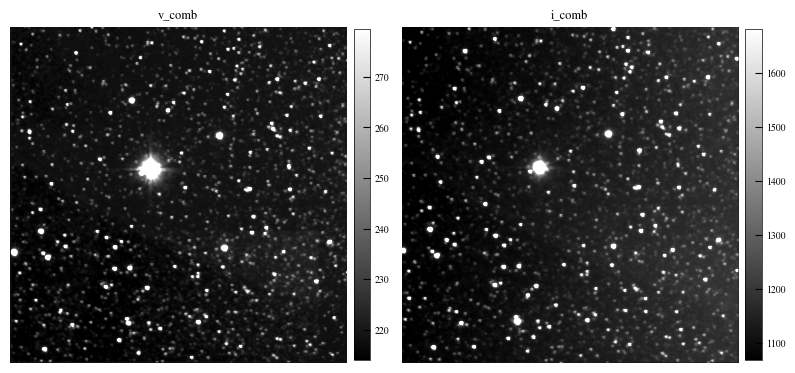

In [13]:
n = len(combs)
fig, axes = plt.subplots(nrows=1, ncols=n, figsize=(8, 3*n))

# Si n == 1, axes no es iterable: lo convertimos en lista
if n == 1:
    axes = [axes]

for i in range(n):
    comb_img = read_fits_data(comb_data_path / combs[i])

    vmin = np.percentile(comb_img, 5)
    vmax = np.percentile(comb_img, 99)

    im = axes[i].imshow(comb_img, origin="lower", cmap="gray",
                         vmin=vmin, vmax=vmax)
    axes[i].set_title(combs[i].split(".")[0][-6:], fontsize=9)
    axes[i].axis("off")

    cb = fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.02)
    cb.ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()


In [18]:
reduced_path = os.path.join(BASE, "data", noche, objname, "phot_REDUCED")
os.listdir(reduced_path)

['FBOGLE-2025-BLG-0675i0006_wcs',
 'OGLE-2025-BLG-0675_i_comb',
 'FBOGLE-2025-BLG-0675v0003_wcs',
 'FBOGLE-2025-BLG-0675i0003_wcs',
 'REDUCED.csv',
 'FBOGLE-2025-BLG-0675v0001_wcs',
 'FBOGLE-2025-BLG-0675v0009_wcs',
 'FBOGLE-2025-BLG-0675v0012_wcs',
 'FBOGLE-2025-BLG-0675v0008_wcs',
 'FBOGLE-2025-BLG-0675v0005_wcs',
 'FailedFiles.dat',
 'FBOGLE-2025-BLG-0675i0004_wcs',
 'FBOGLE-2025-BLG-0675i0002_wcs',
 'FBOGLE-2025-BLG-0675v0004_wcs',
 'OGLE-2025-BLG-0675_v_comb',
 'FBOGLE-2025-BLG-0675v0010_wcs',
 'FBOGLE-2025-BLG-0675i0007_wcs',
 'FBOGLE-2025-BLG-0675i0001_wcs',
 'FBOGLE-2025-BLG-0675v0006_wcs',
 'FBOGLE-2025-BLG-0675v0007_wcs',
 'FBOGLE-2025-BLG-0675i0005_wcs',
 'FBOGLE-2025-BLG-0675i0008_wcs']

[14.59984712,
 14.51768855,
 14.34541639,
 14.46640828,
 14.5464382,
 14.65735911,
 14.52943386,
 14.55241695]

In [ ]:
phot = pd.read_csv(os.path.join(reduced_path, "REDUCED.csv"))
comb_mask = phot["fname"].str.contains("comb", na=False)
comb_phot = phot[comb_mask][["mjd", "I", "I_err", "V", "V_err"]]
comb_i_mask = -comb_phot["I"].isna()
comb_v_mask = -comb_phot["V"].isna()
indiv_mask = phot["fname"].str.contains("FB", na=False)
indiv_phot = phot[indiv_mask][["mjd", "I", "I_err", "V", "V_err"]]
indiv_i_mask = -indiv_phot["I"].isna()
indiv_v_mask = -indiv_phot["V"].isna()
indiv_i = [float(i[1:-1])  for i in indiv_phot["I"].values if isinstance(i, str)]
indiv_mjd_i = indiv_phot[indiv_i_mask]["mjd"]
plt.plot(indiv_mjd_i, indiv_i, "o")
plt.show()

/home/knowogrodski/miniconda3/envs/autophot_env/lib/python3.7/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 9 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/home/knowogrodski/miniconda3/envs/autophot_env/lib/python3.7/site-packages/matplotlib/backends/backend_agg.py:203: RuntimeWarning: Glyph 9 missing from current font.
  font.set_text(s, 0, flags=flags)


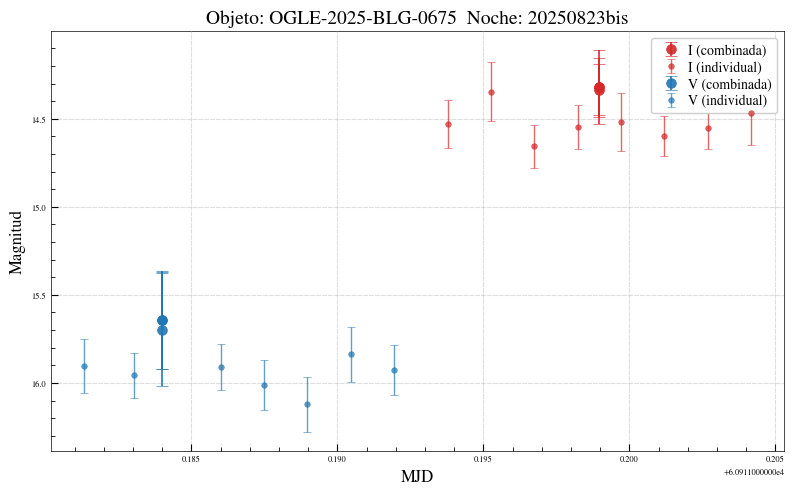

In [81]:
phot = pd.read_csv(os.path.join(reduced_path, "REDUCED.csv"))

# Máscaras para combinadas e individuales
comb_mask = phot["fname"].str.contains("comb", na=False)
indiv_mask = phot["fname"].str.contains("FB", na=False)

# Sub-DataFrames
comb_phot = phot[comb_mask][["mjd", "I", "I_err", "V", "V_err"]].copy()
indiv_phot = phot[indiv_mask][["mjd", "I", "I_err", "V", "V_err"]].copy()

# Función para limpiar magnitudes y errores (maneja listas, strings '[valor]', floats, NaN)
def clean_to_float(series):
    def convert(x):
        if pd.isna(x):
            return np.nan
        if isinstance(x, (list, np.ndarray)) and len(x) == 1:
            return float(x[0])
        if isinstance(x, str):
            if x.startswith('[') and x.endswith(']'):
                try:
                    return float(x[1:-1].strip())
                except:
                    return np.nan
            try:
                return float(x)
            except:
                return np.nan
        try:
            return float(x)
        except:
            return np.nan
    
    return series.apply(convert).astype('float64')

# Aplicar limpieza a todas las columnas relevantes
for col in ['I', 'V', 'I_err', 'V_err']:
    comb_phot[col] = clean_to_float(comb_phot[col])
    indiv_phot[col] = clean_to_float(indiv_phot[col])

# Máscaras de datos válidos (no NaN) después de limpiar
comb_i_mask = comb_phot["I"].notna()
comb_v_mask = comb_phot["V"].notna()
indiv_i_mask = indiv_phot["I"].notna()
indiv_v_mask = indiv_phot["V"].notna()

# ────────────────────────────────────────────────
# Plot con barras de error
# ────────────────────────────────────────────────

plt.figure(figsize=(8, 5))

# Colores y estilos
color_I = '#d62728'   # rojo-anaranjado
color_V = '#1f77b4'   # azul
marker_comb = 'o'
marker_indiv = '.'

# Banda I - Combinadas
plt.errorbar(
    comb_phot[comb_i_mask]['mjd'], 
    comb_phot[comb_i_mask]['I'],
    yerr=comb_phot[comb_i_mask]['I_err'],
    fmt=marker_comb, color=color_I, ecolor=color_I, 
    alpha=0.9, capsize=4, elinewidth=1.3, 
    label='I (combinada)', zorder=10, ms=7
)

# Banda I - Individuales
plt.errorbar(
    indiv_phot[indiv_i_mask]['mjd'], 
    indiv_phot[indiv_i_mask]['I'],
    yerr=indiv_phot[indiv_i_mask]['I_err'],
    fmt=marker_indiv, color=color_I, ecolor=color_I, 
    alpha=0.7, capsize=3, elinewidth=1, 
    label='I (individual)', zorder=5, ms=8
)

# Banda V - Combinadas
plt.errorbar(
    comb_phot[comb_v_mask]['mjd'], 
    comb_phot[comb_v_mask]['V'],
    yerr=comb_phot[comb_v_mask]['V_err'],
    fmt=marker_comb, color=color_V, ecolor=color_V, 
    alpha=0.9, capsize=4, elinewidth=1.3, 
    label='V (combinada)', zorder=10, ms=7
)

# Banda V - Individuales
plt.errorbar(
    indiv_phot[indiv_v_mask]['mjd'], 
    indiv_phot[indiv_v_mask]['V'],
    yerr=indiv_phot[indiv_v_mask]['V_err'],
    fmt=marker_indiv, color=color_V, ecolor=color_V, 
    alpha=0.7, capsize=3, elinewidth=1, 
    label='V (individual)', zorder=5, ms=8
)

plt.xlabel('MJD', fontsize=12)
plt.ylabel('Magnitud', fontsize=12)
plt.title(f'Objeto: {objname}\t Noche: {noche}', fontsize=14)
plt.legend(loc='upper right', fontsize=10, framealpha=0.95)
plt.gca().invert_yaxis()           # Magnitudes más brillantes abajo
plt.grid(True, linestyle='--', alpha=0.4)
plt.minorticks_on()
plt.tight_layout()


plt.savefig(os.path.join(reduced_path, 'lightcurve_I_V.png'), dpi=250, bbox_inches='tight')

plt.show()


In [6]:
from pathlib import Path
p = Path("/home/knowogrodski/Documentos/observation_HSH/process_HSH_SN/pipe_HSH/data/20250823bis/OGLE2025GD0001v0011.fit")
p.parent

PosixPath('/home/knowogrodski/Documentos/observation_HSH/process_HSH_SN/pipe_HSH/data/20250823bis')

In [75]:
phot["fname"].values

array(['/home/knowogrodski/Documentos/observation_HSH/process_HSH_SN/data/20250823bis/OGLE-2025-BLG-0675/phot_REDUCED/OGLE-2025-BLG-0675_v_comb/OGLE-2025-BLG-0675_v_comb_APT.fits',
       '/home/knowogrodski/Documentos/observation_HSH/process_HSH_SN/data/20250823bis/OGLE-2025-BLG-0675/phot_REDUCED/OGLE-2025-BLG-0675_i_comb/OGLE-2025-BLG-0675_i_comb_APT.fits',
       '/home/knowogrodski/Documentos/observation_HSH/process_HSH_SN/data/20250823bis/OGLE-2025-BLG-0675/phot_REDUCED/OGLE-2025-BLG-0675_v_comb/OGLE-2025-BLG-0675_v_comb_APT.fits',
       '/home/knowogrodski/Documentos/observation_HSH/process_HSH_SN/data/20250823bis/OGLE-2025-BLG-0675/phot_REDUCED/OGLE-2025-BLG-0675_i_comb/OGLE-2025-BLG-0675_i_comb_APT.fits',
       '/home/knowogrodski/Documentos/observation_HSH/process_HSH_SN/data/20250823bis/OGLE-2025-BLG-0675/phot_REDUCED/OGLE-2025-BLG-0675_v_comb/OGLE-2025-BLG-0675_v_comb_APT.fits',
       '/home/knowogrodski/Documentos/observation_HSH/process_HSH_SN/data/20250823bis/OGLE-2025

In [52]:
i_mask

5     False
6     False
7      True
9     False
10     True
11    False
12     True
13     True
14    False
15    False
16    False
17     True
18     True
19     True
20     True
Name: I, dtype: bool